In [1]:
import regex as re
import json
import matplotlib.pyplot as plt
import numpy as np


def parse_depth_data(log_text):
    regex = r"\bcorrect by depth:\s*(\{[\d\s:,]+\})"

    matches = re.findall(regex, log_text)
    results = []

    for match in matches:
        string_key_match = re.sub(r'(\d+):', r'"\1":', match)
        try:
            depth_data = json.loads(string_key_match)
            results.append(depth_data)
        except json.JSONDecodeError:
            print(f"Warning: Could not parse as JSON: {string_key_match}")

    return results

def parse_epoch(log_text):
    regex = r".+: (?P<x>.+), .+: (?P<y>.+)\nEPOCH\s+(?P<epoch>\d+).*?len\(train\)=(?P<len_train>\d+).*?\nLOSS train\s+(?P<train_loss>\d+\.\d+).*?\nLOSS validation\s+(?P<val_loss>\d+\.\d+)"

    match = re.search(regex, log_text, re.DOTALL)

    if match:
        return {
            "x": float(match.group("x")),
            "y": float(match.group("y")),
            "epoch": int(match.group("epoch")),
            "len_train": int(match.group("len_train")),
            "train_loss": float(match.group("train_loss")),
            "val_loss": float(match.group("val_loss")),
        }
    else:
        return None

def calculate_accuracy(depth_data):
    correct_predictions = 0
    for i, depth_level_data in enumerate(depth_data):
        for key, value in depth_level_data.items():
            correct_predictions += value
    return correct_predictions / 3000.0 / len(depth_data)


def create_heatmap(data, xs, ys, x_n, y_n):
    heatmap_data = np.full((len(ys), len(xs)), np.nan)

    for (x, y), accuracy in data.items():
        x_idx = xs.index(x)
        y_idx = ys.index(y)
        heatmap_data[y_idx, x_idx] = accuracy

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(heatmap_data, cmap="Blues", interpolation='nearest')

    ax.set_xticks(np.arange(len(xs)))
    ax.set_yticks(np.arange(len(ys)))
    ax.set_xticklabels(xs)
    ax.set_yticklabels(ys)
    ax.set_xlabel(x_n)
    ax.set_ylabel(y_n)
    ax.set_title("Overall Accuracy Heatmap")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Accuracy')

    plt.tight_layout()
    plt.show()

def load(path, T=False):
    all_data = {}
    all_x = set()
    all_y = set()

    with open(path, 'r', encoding='utf-8') as file:
        contents = file.read()

    for c in contents.split("\n\n\n"):
        e, r = c.split("\n\n")
        e_data = parse_epoch(e)
        r_data = parse_depth_data(r)

        norm = lambda x: int(x) if round(float(x)) == float(x) else float(x)

        if e_data and r_data:
            xs = norm(e_data['x'])
            ys = norm(e_data['y'])
            if T:
                xs, ys = ys, xs
            accuracy = calculate_accuracy(r_data)
            all_data[(xs, ys)] = accuracy
            all_x.add(xs)
            all_y.add(ys)

    return all_data, sorted(list(all_x)), sorted(list(all_y))


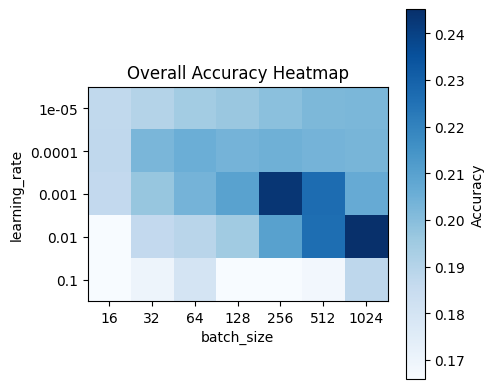

In [2]:
all_data, all_xs, all_ys = load("batch_lr_grid_search_scaled.txt")
create_heatmap(all_data, all_xs, all_ys, 'batch_size', 'learning_rate')

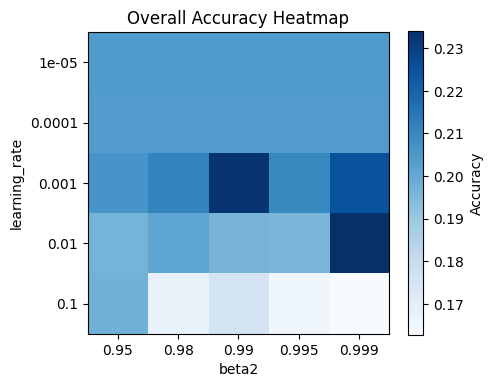

In [3]:
all_data, all_ys, all_xs = load("lr_beta2_grid_search.txt", T=True)
create_heatmap(all_data, all_ys, all_xs, 'beta2', 'learning_rate')

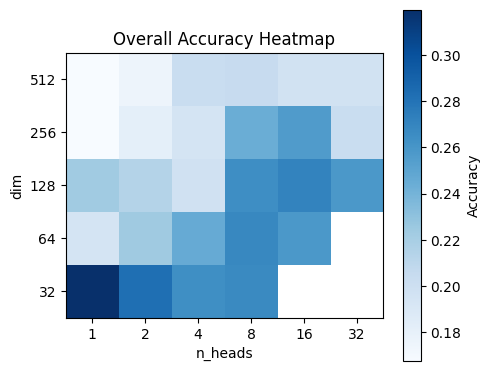

In [4]:
all_data, all_xs, all_ys = load("dim_n_heads_grid_search.txt", T=True)
create_heatmap(all_data, all_xs, list(reversed(all_ys)), 'n_heads', 'dim')

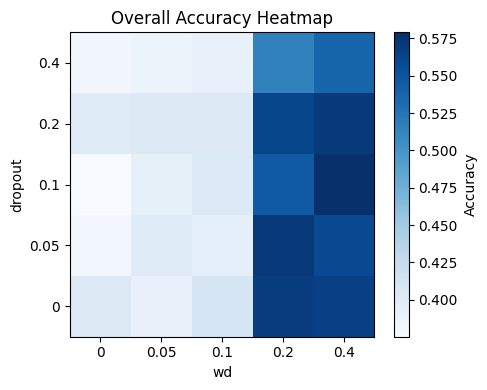

In [7]:
all_data, all_xs, all_ys = load("wd_dropout_grid_search.txt")
create_heatmap(all_data, all_xs, list(reversed(all_ys)), 'wd', 'dropout')